# Examen 3
 
Nombre: <font color = 'cyan'> **Francisco Javier Nava Valecia** </font>
 
### Física Computacional 2023-2

Resuelva los siguientes ejercicios.

1. Se tiene la ecuación diferencial para $P(t)$

$$
\frac{dP}{dt} = rP \left( 1 - \frac{P}{P_1} \right)\left( 1 - \frac{P}{P_2} \right)
$$
 
donde $r$, $P_1$ y $P_2$ son constantes positivas. Genere una función que se pueda utilizar para realizar una integración numérica de la ecuación diferencial y que además tenga como argumentos opcionales las dos constantes anteriores.


In [1]:
def dPdt(t, P, r, P1=100, P2=200): #los opcionales son P1 y P2
    return r * P * (1 - P/P1) * (1 - P/P2)

#Implementación de RK4
import numpy as np

def Integrar_P(P0,t0,tf,h,r,P1=100,P2=200):

    #Numero de pasos
    N = int((tf-t0)/h)

    #Arreglar para guardar resultados
    t = np.zeros(N+1)
    P = np.zeros(N+1)

    #Condiciones iniciales
    t[0] = t0
    P[0] = P0

    #integración RK4
    for i in range(N):
        k1 = dPdt(t[i],P[i],r,P1,P2)
        k2 = dPdt(t[i] + h/2,P[i] + h* k1/2, r, P1, P2)
        k3 = dPdt(t[i] + h/2,P[i] + h* k2/2, r, P1, P2)
        k4 = dPdt(t[i] + h/2,P[i] + h* k3/2, r, P1, P2)

        #Actualización de RK4
        P[i+1] = P[i]  + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

        t[i+1] = t[i] + h
    return t, P

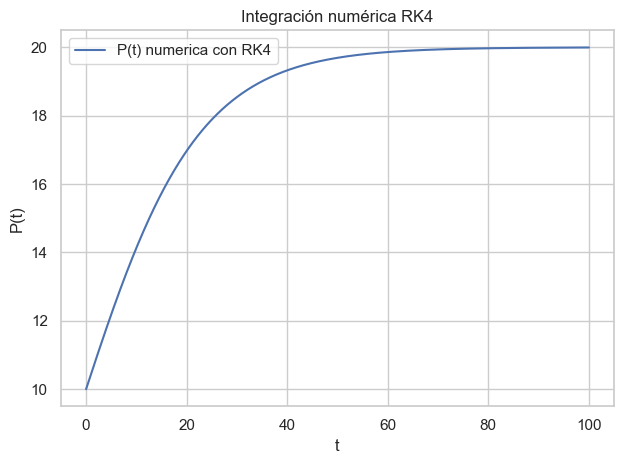

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parámetros
r = 0.1

#Pedir a los alumosn que los valores opcionales sean estos para que todos vayamos parejos
P1 = 100
P2 = 20

# Condición inicial
P0 = 10

# Intervalo de tiempo
t0 = 0
tf = 100

# Tamaño de paso
h = 0.1

# Integración
t, P = Integrar_P(P0, t0, tf, h, r, P1, P2)

sns.set_theme(style="whitegrid")
sns.lineplot(x=t,y=P,label = f"P(t) numerica con RK4")
plt.xlabel("t")
plt.ylabel("P(t)")
plt.title("Integración numérica RK4")


plt.legend()
plt.tight_layout()
plt.show()

 2. Utilice la función [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) de scipy para encontrar la solución numérica de la ecuación anterior para $r=0.6$, $P_1 = 12$, $P_2 = 20$ y las condiciones iniciales $P(0) = \{1,3,5, ... 25 \}$

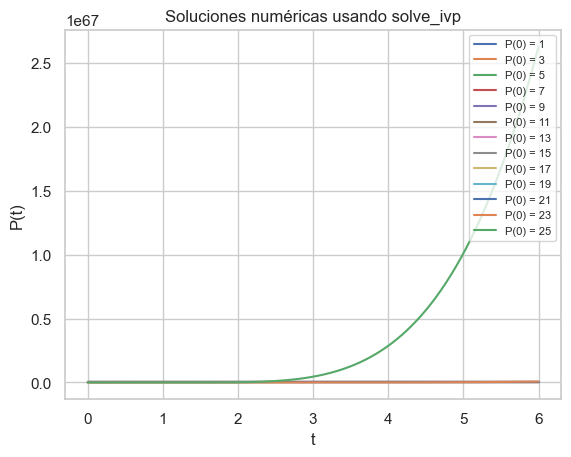

In [24]:
from scipy.integrate import solve_ivp

#Parametros
r = 0.6
P1 = 12
P2 = 20

t_span = (0,6)
# Puntos donde evaluar la solución
t = np.linspace(0, t_span[1], 1000)

P0_list = np.arange(1,26,2)

sns.set_theme(style='whitegrid')
for Ci in P0_list:
    solv_ivp = solve_ivp(dPdt,t_span,[Ci],
                         dense_output=True,
                         args=(r,P1,P2))
    
    sns.lineplot(x=t, y=solv_ivp.sol(t)[0],  #se grafica cada solucion correspodiente a cada condicion inicial
             label=f'P(0) = {int(Ci)}'
             )

# Etiquetas y formato
plt.xlabel('t')
plt.ylabel('P(t)')
plt.title('Soluciones numéricas usando solve_ivp')

plt.legend(
    fontsize=8,
    loc='upper right'
)

plt.grid(True)
plt.show()


3. Suponga el caso en el que $P_2 \to \infty ^+$ y que $P(0)=5$ del problema anterior. Encuentre la máxima diferencia dicha solución y la función
$$
P(t) = \frac{ 60e^{3t/5} }{ 7+5e^{3t/5}}
$$

Máxima diferencia: 0.009659725928027996


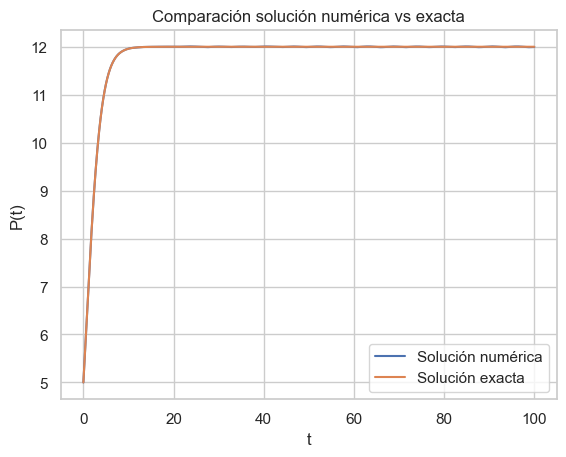

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp


# EDO logística (P2 -> infinito)
def dPdt_inf(t, P, r, P1):
    return r * P * (1 - P/P1)


# Solución exacta
def Pt(t):
    return (60 * np.exp(3*t/5)) / (7 + 5*np.exp(3*t/5))


# Parámetros
r = 0.6
P1 = 12
P0 = 5

# Intervalo temporal
t_span = (0, 100)

# Puntos de evaluación
t = np.linspace(0, 100, 1000)

# Resolver numéricamente
sol = solve_ivp(dPdt_inf,t_span,[P0],t_eval=t,args=(r, P1))

# Solución numérica
P_num = sol.y[0]

# Solución exacta
P_exacta = Pt(t)

# Diferencia absoluta
diff = np.abs(P_num - P_exacta)

# Máxima diferencia
max_diff = np.max(diff)

print("Máxima diferencia:", max_diff)

# Gráficas
sns.set_theme(style='whitegrid')

sns.lineplot(x=t,y=P_num,label='Solución numérica')

sns.lineplot(x=t,y=P_exacta,label='Solución exacta')

plt.xlabel('t')
plt.ylabel('P(t)')
plt.title('Comparación solución numérica vs exacta')

plt.legend()
plt.grid(True)
plt.show()